<a href="https://colab.research.google.com/github/arfadhiq/Feedback-Enhanced-Data-Synthesis/blob/main/EDA_and_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mohamed Arfadh Iqbal
# Individual Research Project


# **Load the Dataset**

In [1]:
import kagglehub
import pandas as pd
import os

# 1. Download the latest version
path = kagglehub.dataset_download("ismetsemedov/transactions")

print("Path to dataset files:", path)

# 2. List the files in the directory to see the filenames
files = os.listdir(path)
print("Files in directory:", files)

100%|██████████| 754M/754M [00:53<00:00, 14.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ismetsemedov/transactions/versions/1
Files in directory: ['synthetic_fraud_data.csv']


In [2]:
# 3. Join the path with the specific filename
# Note: Check the output of the previous cell to confirm the exact filename
file_name = 'synthetic_fraud_data.csv' # This is the typical name for this dataset
full_path = os.path.join(path, file_name)

# 4. Load into DataFrame
df = pd.read_csv(full_path)

# 5. Preview the data
df.head()

,transaction_id,customer_id,card_number,timestamp,merchant_category,merchant_type,merchant,amount,currency,country,...,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
0,TX_a0ad2a2a,CUST_72886,6646734767813109,2024-09-30 00:00:01.034820+00:00,Restaurant,fast_food,Taco Bell,294.87,GBP,UK,...,iOS App,mobile,e8e6160445c935fd0001501e4cbac8bc,197.153.60.199,0,False,0,False,"{'num_transactions': 1197, 'total_amount': 334...",False
1,TX_3599c101,CUST_70474,376800864692727,2024-09-30 00:00:01.764464+00:00,Entertainment,gaming,Steam,3368.97,BRL,Brazil,...,Edge,web,a73043a57091e775af37f252b3a32af9,208.123.221.203,1,True,0,False,"{'num_transactions': 509, 'total_amount': 2011...",True
2,TX_a9461c6d,CUST_10715,5251909460951913,2024-09-30 00:00:02.273762+00:00,Grocery,physical,Whole Foods,102582.38,JPY,Japan,...,Firefox,web,218864e94ceaa41577d216b149722261,10.194.159.204,0,False,0,False,"{'num_transactions': 332, 'total_amount': 3916...",False
3,TX_7be21fc4,CUST_16193,376079286931183,2024-09-30 00:00:02.297466+00:00,Gas,major,Exxon,630.60,AUD,Australia,...,iOS App,mobile,70423fa3a1e74d01203cf93b51b9631d,17.230.177.225,0,False,0,False,"{'num_transactions': 764, 'total_amount': 2201...",False
4,TX_150f490b,CUST_87572,6172948052178810,2024-09-30 00:00:02.544063+00:00,Healthcare,medical,Medical Center,724949.27,NGN,Nigeria,...,Chrome,web,9880776c7b6038f2af86bd4e18a1b1a4,136.241.219.151,1,False,0,False,"{'num_transactions': 218, 'total_amount': 4827...",True


In [3]:
df

,transaction_id,customer_id,card_number,timestamp,merchant_category,merchant_type,merchant,amount,currency,country,...,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
0,TX_a0ad2a2a,CUST_72886,6646734767813109,2024-09-30 00:00:01.034820+00:00,Restaurant,fast_food,Taco Bell,294.87,GBP,UK,...,iOS App,mobile,e8e6160445c935fd0001501e4cbac8bc,197.153.60.199,0,False,0,False,"{'num_transactions': 1197, 'total_amount': 334...",False
1,TX_3599c101,CUST_70474,376800864692727,2024-09-30 00:00:01.764464+00:00,Entertainment,gaming,Steam,3368.97,BRL,Brazil,...,Edge,web,a73043a57091e775af37f252b3a32af9,208.123.221.203,1,True,0,False,"{'num_transactions': 509, 'total_amount': 2011...",True
2,TX_a9461c6d,CUST_10715,5251909460951913,2024-09-30 00:00:02.273762+00:00,Grocery,physical,Whole Foods,102582.38,JPY,Japan,...,Firefox,web,218864e94ceaa41577d216b149722261,10.194.159.204,0,False,0,False,"{'num_transactions': 332, 'total_amount': 3916...",False
3,TX_7be21fc4,CUST_16193,376079286931183,2024-09-30 00:00:02.297466+00:00,Gas,major,Exxon,630.60,AUD,Australia,...,iOS App,mobile,70423fa3a1e74d01203cf93b51b9631d,17.230.177.225,0,False,0,False,"{'num_transactions': 764, 'total_amount': 2201...",False
4,TX_150f490b,CUST_87572,6172948052178810,2024-09-30 00:00:02.544063+00:00,Healthcare,medical,Medical Center,724949.27,NGN,Nigeria,...,Chrome,web,9880776c7b6038f2af86bd4e18a1b1a4,136.241.219.151,1,False,0,False,"{'num_transactions': 218, 'total_amount': 4827...",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7483761,TX_58a762fa,CUST_11344,377055034743699,2024-10-30 23:59:58.926575+00:00,Retail,online,AliExpress,887.32,SGD,Singapore,...,Safari,web,2e37bb086e754bfaf2ec3806dcac8d98,248.8.111.152,0,False,23,False,"{'num_transactions': 1, 'total_amount': 1521.7...",False
7483762,TX_dabcf671,CUST_38961,373625915641065,2024-10-30 23:59:58.950801+00:00,Grocery,physical,Kroger,356.06,EUR,France,...,Chrome,web,459c67dbfbb15019df8088fc0f2ffe1d,224.123.137.90,0,False,23,False,"{'num_transactions': 0, 'total_amount': 356.06...",False
7483763,TX_ab567eb4,CUST_75576,6702342842796660,2024-10-30 23:59:58.972155+00:00,Grocery,physical,Kroger,391.96,SGD,Singapore,...,Safari,web,337d36a8f5e811564a1dd3c255db01dd,31.196.9.234,0,False,23,False,"{'num_transactions': 0, 'total_amount': 391.96...",False
7483764,TX_5ae61846,CUST_82508,374615717295581,2024-10-30 23:59:58.996608+00:00,Retail,online,eBay,601.71,USD,USA,...,Firefox,web,52874c17f4ab0846fac1aed0c66e8551,188.74.107.8,0,False,23,False,"{'num_transactions': 2, 'total_amount': 1474.5...",False


In [4]:
df_sample = df.head(5).copy()

In [5]:
df_sample

,transaction_id,customer_id,card_number,timestamp,merchant_category,merchant_type,merchant,amount,currency,country,...,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
0,TX_a0ad2a2a,CUST_72886,6646734767813109,2024-09-30 00:00:01.034820+00:00,Restaurant,fast_food,Taco Bell,294.87,GBP,UK,...,iOS App,mobile,e8e6160445c935fd0001501e4cbac8bc,197.153.60.199,0,False,0,False,"{'num_transactions': 1197, 'total_amount': 334...",False
1,TX_3599c101,CUST_70474,376800864692727,2024-09-30 00:00:01.764464+00:00,Entertainment,gaming,Steam,3368.97,BRL,Brazil,...,Edge,web,a73043a57091e775af37f252b3a32af9,208.123.221.203,1,True,0,False,"{'num_transactions': 509, 'total_amount': 2011...",True
2,TX_a9461c6d,CUST_10715,5251909460951913,2024-09-30 00:00:02.273762+00:00,Grocery,physical,Whole Foods,102582.38,JPY,Japan,...,Firefox,web,218864e94ceaa41577d216b149722261,10.194.159.204,0,False,0,False,"{'num_transactions': 332, 'total_amount': 3916...",False
3,TX_7be21fc4,CUST_16193,376079286931183,2024-09-30 00:00:02.297466+00:00,Gas,major,Exxon,630.60,AUD,Australia,...,iOS App,mobile,70423fa3a1e74d01203cf93b51b9631d,17.230.177.225,0,False,0,False,"{'num_transactions': 764, 'total_amount': 2201...",False
4,TX_150f490b,CUST_87572,6172948052178810,2024-09-30 00:00:02.544063+00:00,Healthcare,medical,Medical Center,724949.27,NGN,Nigeria,...,Chrome,web,9880776c7b6038f2af86bd4e18a1b1a4,136.241.219.151,1,False,0,False,"{'num_transactions': 218, 'total_amount': 4827...",True


In [ ]:
df_sample.to_csv('sample.csv', index=False)

# **EDA**

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast


In [7]:
df

,transaction_id,customer_id,card_number,timestamp,merchant_category,merchant_type,merchant,amount,currency,country,...,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
0,TX_a0ad2a2a,CUST_72886,6646734767813109,2024-09-30 00:00:01.034820+00:00,Restaurant,fast_food,Taco Bell,294.87,GBP,UK,...,iOS App,mobile,e8e6160445c935fd0001501e4cbac8bc,197.153.60.199,0,False,0,False,"{'num_transactions': 1197, 'total_amount': 334...",False
1,TX_3599c101,CUST_70474,376800864692727,2024-09-30 00:00:01.764464+00:00,Entertainment,gaming,Steam,3368.97,BRL,Brazil,...,Edge,web,a73043a57091e775af37f252b3a32af9,208.123.221.203,1,True,0,False,"{'num_transactions': 509, 'total_amount': 2011...",True
2,TX_a9461c6d,CUST_10715,5251909460951913,2024-09-30 00:00:02.273762+00:00,Grocery,physical,Whole Foods,102582.38,JPY,Japan,...,Firefox,web,218864e94ceaa41577d216b149722261,10.194.159.204,0,False,0,False,"{'num_transactions': 332, 'total_amount': 3916...",False
3,TX_7be21fc4,CUST_16193,376079286931183,2024-09-30 00:00:02.297466+00:00,Gas,major,Exxon,630.60,AUD,Australia,...,iOS App,mobile,70423fa3a1e74d01203cf93b51b9631d,17.230.177.225,0,False,0,False,"{'num_transactions': 764, 'total_amount': 2201...",False
4,TX_150f490b,CUST_87572,6172948052178810,2024-09-30 00:00:02.544063+00:00,Healthcare,medical,Medical Center,724949.27,NGN,Nigeria,...,Chrome,web,9880776c7b6038f2af86bd4e18a1b1a4,136.241.219.151,1,False,0,False,"{'num_transactions': 218, 'total_amount': 4827...",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7483761,TX_58a762fa,CUST_11344,377055034743699,2024-10-30 23:59:58.926575+00:00,Retail,online,AliExpress,887.32,SGD,Singapore,...,Safari,web,2e37bb086e754bfaf2ec3806dcac8d98,248.8.111.152,0,False,23,False,"{'num_transactions': 1, 'total_amount': 1521.7...",False
7483762,TX_dabcf671,CUST_38961,373625915641065,2024-10-30 23:59:58.950801+00:00,Grocery,physical,Kroger,356.06,EUR,France,...,Chrome,web,459c67dbfbb15019df8088fc0f2ffe1d,224.123.137.90,0,False,23,False,"{'num_transactions': 0, 'total_amount': 356.06...",False
7483763,TX_ab567eb4,CUST_75576,6702342842796660,2024-10-30 23:59:58.972155+00:00,Grocery,physical,Kroger,391.96,SGD,Singapore,...,Safari,web,337d36a8f5e811564a1dd3c255db01dd,31.196.9.234,0,False,23,False,"{'num_transactions': 0, 'total_amount': 391.96...",False
7483764,TX_5ae61846,CUST_82508,374615717295581,2024-10-30 23:59:58.996608+00:00,Retail,online,eBay,601.71,USD,USA,...,Firefox,web,52874c17f4ab0846fac1aed0c66e8551,188.74.107.8,0,False,23,False,"{'num_transactions': 2, 'total_amount': 1474.5...",False


In [8]:
df_main= df.copy()

In [ ]:
df= df.head(5000).copy()

In [9]:
df= df_main.copy()

In [10]:
df

,transaction_id,customer_id,card_number,timestamp,merchant_category,merchant_type,merchant,amount,currency,country,...,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
0,TX_a0ad2a2a,CUST_72886,6646734767813109,2024-09-30 00:00:01.034820+00:00,Restaurant,fast_food,Taco Bell,294.87,GBP,UK,...,iOS App,mobile,e8e6160445c935fd0001501e4cbac8bc,197.153.60.199,0,False,0,False,"{'num_transactions': 1197, 'total_amount': 334...",False
1,TX_3599c101,CUST_70474,376800864692727,2024-09-30 00:00:01.764464+00:00,Entertainment,gaming,Steam,3368.97,BRL,Brazil,...,Edge,web,a73043a57091e775af37f252b3a32af9,208.123.221.203,1,True,0,False,"{'num_transactions': 509, 'total_amount': 2011...",True
2,TX_a9461c6d,CUST_10715,5251909460951913,2024-09-30 00:00:02.273762+00:00,Grocery,physical,Whole Foods,102582.38,JPY,Japan,...,Firefox,web,218864e94ceaa41577d216b149722261,10.194.159.204,0,False,0,False,"{'num_transactions': 332, 'total_amount': 3916...",False
3,TX_7be21fc4,CUST_16193,376079286931183,2024-09-30 00:00:02.297466+00:00,Gas,major,Exxon,630.60,AUD,Australia,...,iOS App,mobile,70423fa3a1e74d01203cf93b51b9631d,17.230.177.225,0,False,0,False,"{'num_transactions': 764, 'total_amount': 2201...",False
4,TX_150f490b,CUST_87572,6172948052178810,2024-09-30 00:00:02.544063+00:00,Healthcare,medical,Medical Center,724949.27,NGN,Nigeria,...,Chrome,web,9880776c7b6038f2af86bd4e18a1b1a4,136.241.219.151,1,False,0,False,"{'num_transactions': 218, 'total_amount': 4827...",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7483761,TX_58a762fa,CUST_11344,377055034743699,2024-10-30 23:59:58.926575+00:00,Retail,online,AliExpress,887.32,SGD,Singapore,...,Safari,web,2e37bb086e754bfaf2ec3806dcac8d98,248.8.111.152,0,False,23,False,"{'num_transactions': 1, 'total_amount': 1521.7...",False
7483762,TX_dabcf671,CUST_38961,373625915641065,2024-10-30 23:59:58.950801+00:00,Grocery,physical,Kroger,356.06,EUR,France,...,Chrome,web,459c67dbfbb15019df8088fc0f2ffe1d,224.123.137.90,0,False,23,False,"{'num_transactions': 0, 'total_amount': 356.06...",False
7483763,TX_ab567eb4,CUST_75576,6702342842796660,2024-10-30 23:59:58.972155+00:00,Grocery,physical,Kroger,391.96,SGD,Singapore,...,Safari,web,337d36a8f5e811564a1dd3c255db01dd,31.196.9.234,0,False,23,False,"{'num_transactions': 0, 'total_amount': 391.96...",False
7483764,TX_5ae61846,CUST_82508,374615717295581,2024-10-30 23:59:58.996608+00:00,Retail,online,eBay,601.71,USD,USA,...,Firefox,web,52874c17f4ab0846fac1aed0c66e8551,188.74.107.8,0,False,23,False,"{'num_transactions': 2, 'total_amount': 1474.5...",False


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [12]:
df.columns

Index(['transaction_id', 'customer_id', 'card_number', 'timestamp',
       'merchant_category', 'merchant_type', 'merchant', 'amount', 'currency',
       'country', 'city', 'city_size', 'card_type', 'card_present', 'device',
       'channel', 'device_fingerprint', 'ip_address', 'distance_from_home',
       'high_risk_merchant', 'transaction_hour', 'weekend_transaction',
       'velocity_last_hour', 'is_fraud'],
      dtype='object')

In [13]:
df_main.columns

Index(['transaction_id', 'customer_id', 'card_number', 'timestamp',
       'merchant_category', 'merchant_type', 'merchant', 'amount', 'currency',
       'country', 'city', 'city_size', 'card_type', 'card_present', 'device',
       'channel', 'device_fingerprint', 'ip_address', 'distance_from_home',
       'high_risk_merchant', 'transaction_hour', 'weekend_transaction',
       'velocity_last_hour', 'is_fraud'],
      dtype='object')

In [14]:
import pandas as pd
import numpy as np

# 1. Remove the ID columns and the raw velocity column
cols_to_drop = ['transaction_id', 'customer_id']
df = df.drop(columns=cols_to_drop)

In [15]:
# 2. Convert timestamp to Date only (YYYY-MM-DD)
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', errors='coerce').dt.date

# 3. Rename it to 'date' for clarity (optional)
df = df.rename(columns={'timestamp': 'date'})

# 4. Preview the cleaned structure
print("Remaining Columns:", df.columns.tolist())
df.head()

Remaining Columns: ['card_number', 'date', 'merchant_category', 'merchant_type', 'merchant', 'amount', 'currency', 'country', 'city', 'city_size', 'card_type', 'card_present', 'device', 'channel', 'device_fingerprint', 'ip_address', 'distance_from_home', 'high_risk_merchant', 'transaction_hour', 'weekend_transaction', 'velocity_last_hour', 'is_fraud']


,card_number,date,merchant_category,merchant_type,merchant,amount,currency,country,city,city_size,...,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
0,6646734767813109,2024-09-30,Restaurant,fast_food,Taco Bell,294.87,GBP,UK,Unknown City,medium,...,iOS App,mobile,e8e6160445c935fd0001501e4cbac8bc,197.153.60.199,0,False,0,False,"{'num_transactions': 1197, 'total_amount': 334...",False
1,376800864692727,2024-09-30,Entertainment,gaming,Steam,3368.97,BRL,Brazil,Unknown City,medium,...,Edge,web,a73043a57091e775af37f252b3a32af9,208.123.221.203,1,True,0,False,"{'num_transactions': 509, 'total_amount': 2011...",True
2,5251909460951913,2024-09-30,Grocery,physical,Whole Foods,102582.38,JPY,Japan,Unknown City,medium,...,Firefox,web,218864e94ceaa41577d216b149722261,10.194.159.204,0,False,0,False,"{'num_transactions': 332, 'total_amount': 3916...",False
3,376079286931183,2024-09-30,Gas,major,Exxon,630.60,AUD,Australia,Unknown City,medium,...,iOS App,mobile,70423fa3a1e74d01203cf93b51b9631d,17.230.177.225,0,False,0,False,"{'num_transactions': 764, 'total_amount': 2201...",False
4,6172948052178810,2024-09-30,Healthcare,medical,Medical Center,724949.27,NGN,Nigeria,Unknown City,medium,...,Chrome,web,9880776c7b6038f2af86bd4e18a1b1a4,136.241.219.151,1,False,0,False,"{'num_transactions': 218, 'total_amount': 4827...",True


In [16]:
df

,card_number,date,merchant_category,merchant_type,merchant,amount,currency,country,city,city_size,...,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
0,6646734767813109,2024-09-30,Restaurant,fast_food,Taco Bell,294.87,GBP,UK,Unknown City,medium,...,iOS App,mobile,e8e6160445c935fd0001501e4cbac8bc,197.153.60.199,0,False,0,False,"{'num_transactions': 1197, 'total_amount': 334...",False
1,376800864692727,2024-09-30,Entertainment,gaming,Steam,3368.97,BRL,Brazil,Unknown City,medium,...,Edge,web,a73043a57091e775af37f252b3a32af9,208.123.221.203,1,True,0,False,"{'num_transactions': 509, 'total_amount': 2011...",True
2,5251909460951913,2024-09-30,Grocery,physical,Whole Foods,102582.38,JPY,Japan,Unknown City,medium,...,Firefox,web,218864e94ceaa41577d216b149722261,10.194.159.204,0,False,0,False,"{'num_transactions': 332, 'total_amount': 3916...",False
3,376079286931183,2024-09-30,Gas,major,Exxon,630.60,AUD,Australia,Unknown City,medium,...,iOS App,mobile,70423fa3a1e74d01203cf93b51b9631d,17.230.177.225,0,False,0,False,"{'num_transactions': 764, 'total_amount': 2201...",False
4,6172948052178810,2024-09-30,Healthcare,medical,Medical Center,724949.27,NGN,Nigeria,Unknown City,medium,...,Chrome,web,9880776c7b6038f2af86bd4e18a1b1a4,136.241.219.151,1,False,0,False,"{'num_transactions': 218, 'total_amount': 4827...",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7483761,377055034743699,2024-10-30,Retail,online,AliExpress,887.32,SGD,Singapore,Unknown City,medium,...,Safari,web,2e37bb086e754bfaf2ec3806dcac8d98,248.8.111.152,0,False,23,False,"{'num_transactions': 1, 'total_amount': 1521.7...",False
7483762,373625915641065,2024-10-30,Grocery,physical,Kroger,356.06,EUR,France,Unknown City,medium,...,Chrome,web,459c67dbfbb15019df8088fc0f2ffe1d,224.123.137.90,0,False,23,False,"{'num_transactions': 0, 'total_amount': 356.06...",False
7483763,6702342842796660,2024-10-30,Grocery,physical,Kroger,391.96,SGD,Singapore,Unknown City,medium,...,Safari,web,337d36a8f5e811564a1dd3c255db01dd,31.196.9.234,0,False,23,False,"{'num_transactions': 0, 'total_amount': 391.96...",False
7483764,374615717295581,2024-10-30,Retail,online,eBay,601.71,USD,USA,Chicago,large,...,Firefox,web,52874c17f4ab0846fac1aed0c66e8551,188.74.107.8,0,False,23,False,"{'num_transactions': 2, 'total_amount': 1474.5...",False


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7483766 entries, 0 to 7483765
Data columns (total 22 columns):
 #   Column               Dtype  
---  ------               -----  
 0   card_number          int64  
 1   date                 object 
 2   merchant_category    object 
 3   merchant_type        object 
 4   merchant             object 
 5   amount               float64
 6   currency             object 
 7   country              object 
 8   city                 object 
 9   city_size            object 
 10  card_type            object 
 11  card_present         bool   
 12  device               object 
 13  channel              object 
 14  device_fingerprint   object 
 15  ip_address           object 
 16  distance_from_home   int64  
 17  high_risk_merchant   bool   
 18  transaction_hour     int64  
 19  weekend_transaction  bool   
 20  velocity_last_hour   object 
 21  is_fraud             bool   
dtypes: bool(4), float64(1), int64(3), object(14)
memory usage: 1.0+ GB

In [19]:
df.describe()

,card_number,amount,distance_from_home,transaction_hour
count,7.483766e+06,7.483766e+06,7.483766e+06,7.483766e+06
mean,4.222100e+15,4.792468e+04,3.220519e-01,1.215467e+01
std,2.341170e+15,1.775562e+05,4.672628e-01,6.536767e+00
min,3.700086e+14,1.000000e-02,0.000000e+00,0.000000e+00
25%,4.004400e+15,3.635300e+02,0.000000e+00,7.000000e+00
50%,5.010745e+15,1.177450e+03,0.000000e+00,1.200000e+01
75%,5.999914e+15,2.242953e+04,1.000000e+00,1.800000e+01
max,6.999728e+15,6.253153e+06,1.000000e+00,2.300000e+01


/tmp/ipykernel_5239/2366492612.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_by_country.index, y=fraud_by_country.values, palette='viridis')


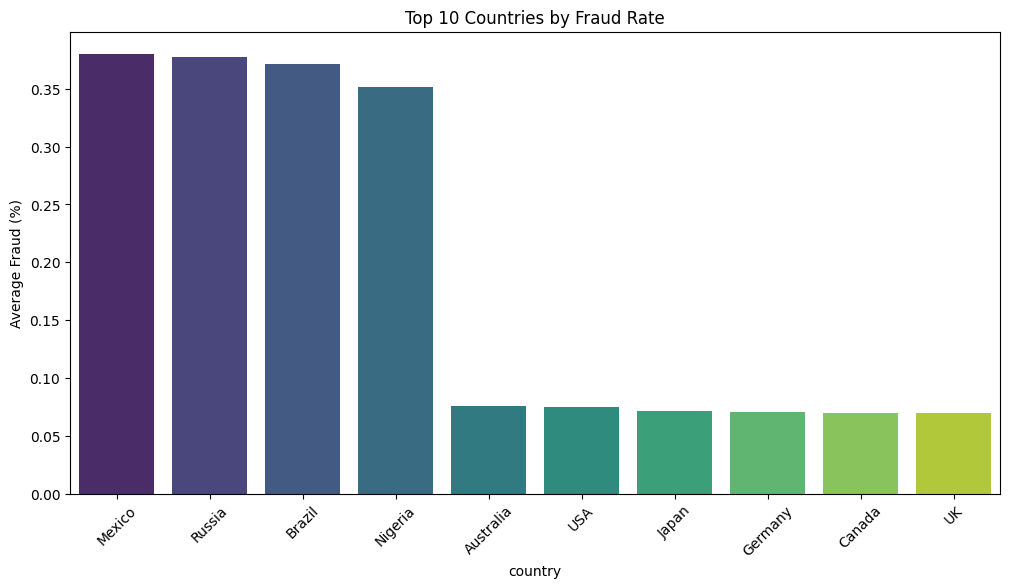

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
# Calculate fraud rate per country
fraud_by_country = df.groupby('country')['is_fraud'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=fraud_by_country.index, y=fraud_by_country.values, palette='viridis')
plt.title('Top 10 Countries by Fraud Rate')
plt.ylabel('Average Fraud (%)')
plt.xticks(rotation=45)
plt.show()

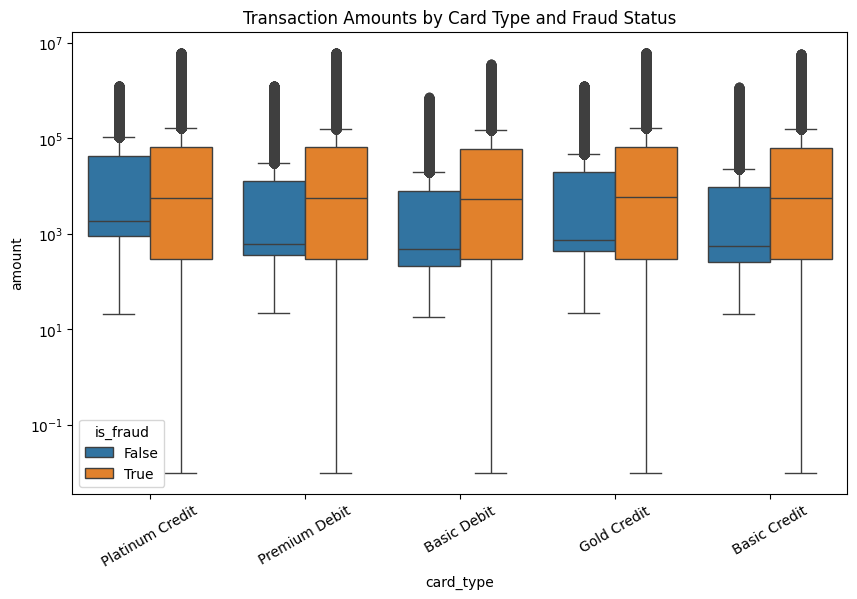

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='card_type', y='amount', hue='is_fraud')
plt.yscale('log') # Log scale helps manage extreme transaction amounts
plt.title('Transaction Amounts by Card Type and Fraud Status')
plt.xticks(rotation=30)
plt.show()

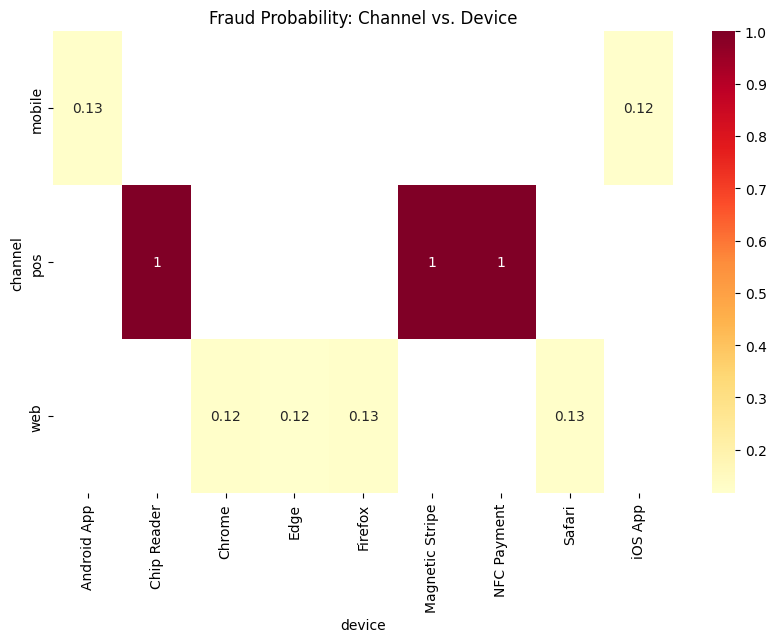

In [22]:
plt.figure(figsize=(10, 6))
sns.heatmap(pd.crosstab(df['channel'], df['device'], values=df['is_fraud'], aggfunc='mean'),
            annot=True, cmap='YlOrRd')
plt.title('Fraud Probability: Channel vs. Device')
plt.show()

Numerical Summary:


,card_number,amount,distance_from_home,transaction_hour
count,7.483766e+06,7.483766e+06,7.483766e+06,7.483766e+06
mean,4.222100e+15,4.792468e+04,3.220519e-01,1.215467e+01
std,2.341170e+15,1.775562e+05,4.672628e-01,6.536767e+00
min,3.700086e+14,1.000000e-02,0.000000e+00,0.000000e+00
25%,4.004400e+15,3.635300e+02,0.000000e+00,7.000000e+00
50%,5.010745e+15,1.177450e+03,0.000000e+00,1.200000e+01
75%,5.999914e+15,2.242953e+04,1.000000e+00,1.800000e+01
max,6.999728e+15,6.253153e+06,1.000000e+00,2.300000e+01


/tmp/ipykernel_5239/2495173113.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='is_fraud', palette='coolwarm')


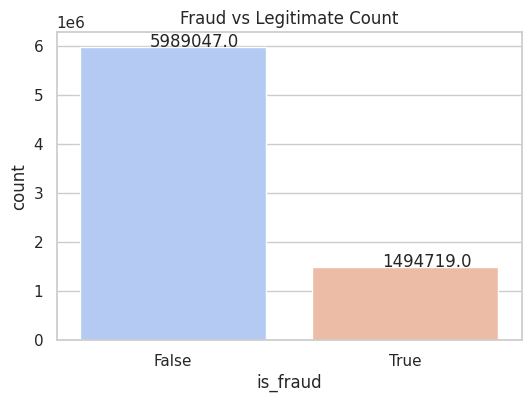

In [23]:
# Set visual style
sns.set_theme(style="whitegrid")

# 1. Statistical Summary
print("Numerical Summary:")
display(df.describe())

# 2. Fraud Balance
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='is_fraud', palette='coolwarm')
plt.title('Fraud vs Legitimate Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x()+0.3, p.get_height()+100))
plt.show()

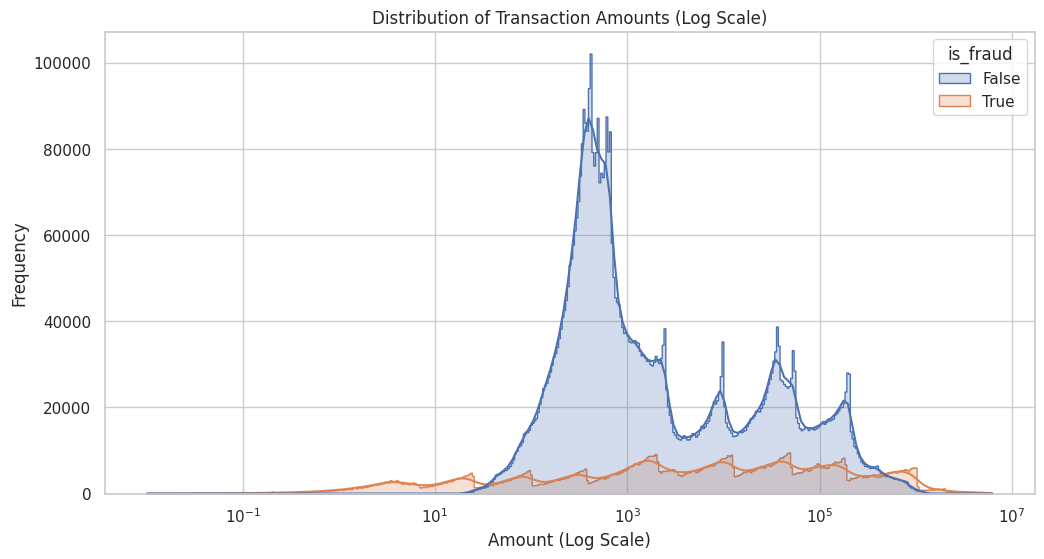

In [24]:
plt.figure(figsize=(12, 6))

# Use log scale because transaction amounts often vary from 1.00 to 1,000,000.00
sns.histplot(data=df, x='amount', hue='is_fraud', kde=True, element="step", log_scale=True)
plt.title('Distribution of Transaction Amounts (Log Scale)')
plt.xlabel('Amount (Log Scale)')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_5239/589504980.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_risk.values, y=country_risk.index, palette='Reds_r')


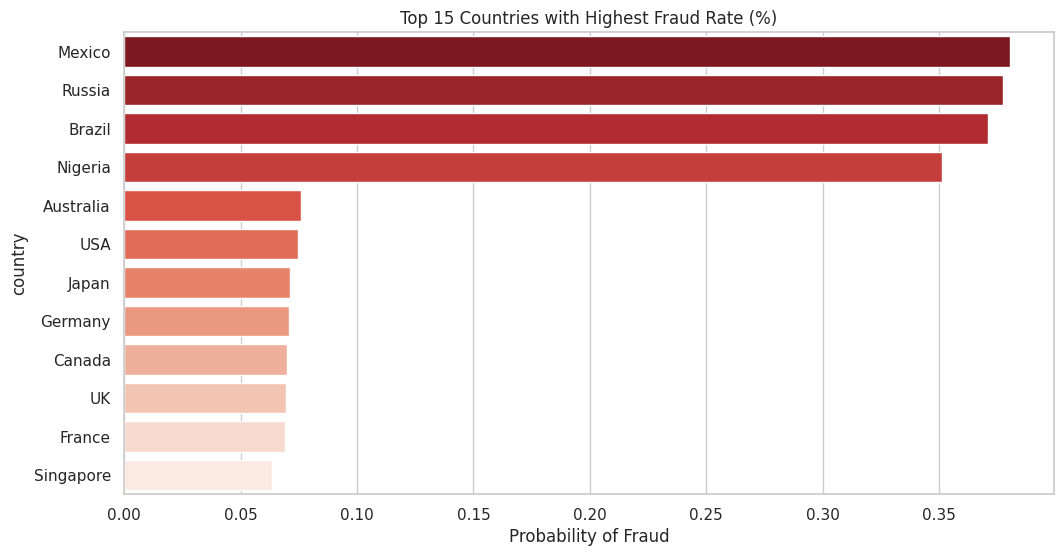

In [25]:
# Grouping by country to see fraud rate
country_risk = df.groupby('country')['is_fraud'].mean().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_risk.values, y=country_risk.index, palette='Reds_r')
plt.title('Top 15 Countries with Highest Fraud Rate (%)')
plt.xlabel('Probability of Fraud')
plt.show()

/tmp/ipykernel_5239/1112575400.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='is_fraud', y='merchant_category', order=order, ax=ax[1], palette='magma')


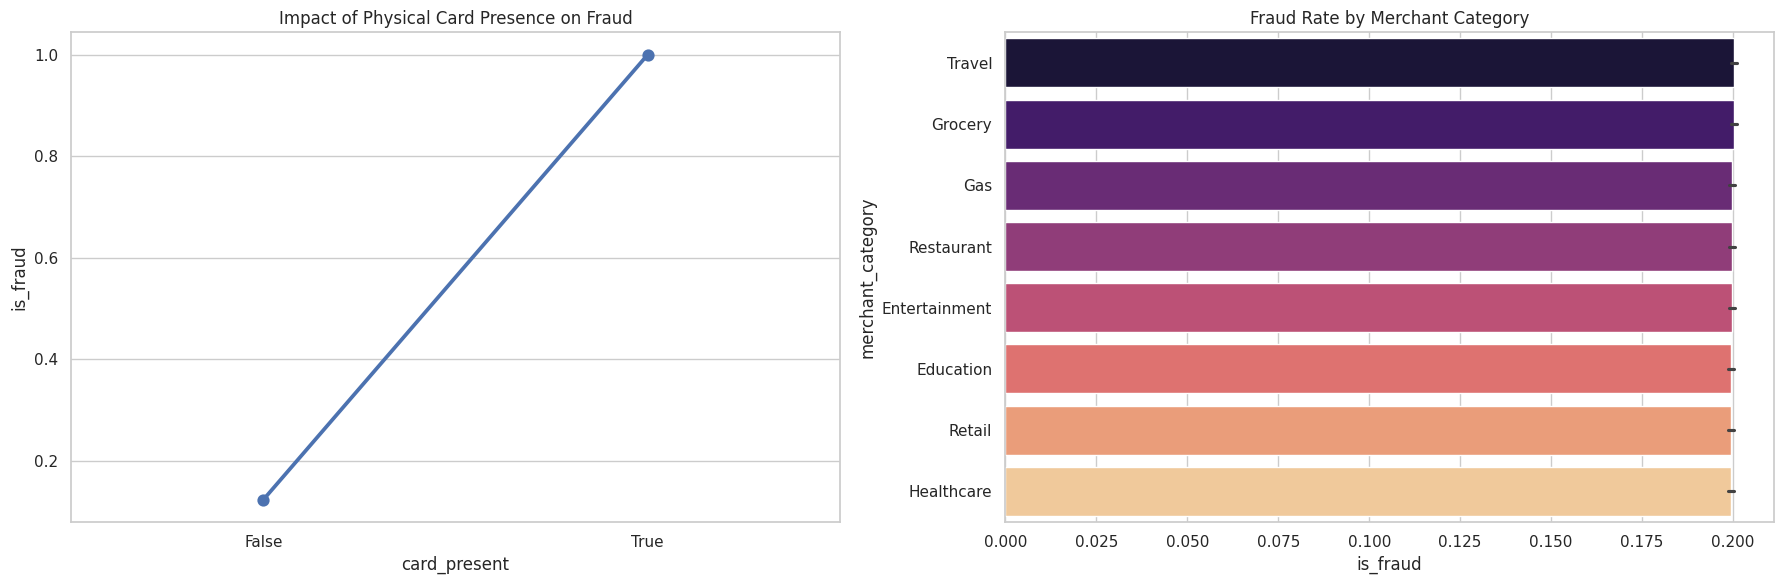

In [26]:
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# 1. Card Present vs Fraud
sns.pointplot(data=df, x='card_present', y='is_fraud', ax=ax[0])
ax[0].set_title('Impact of Physical Card Presence on Fraud')

# 2. Merchant Category vs Fraud
# We calculate the mean to see the 'rate' of fraud
order = df.groupby('merchant_category')['is_fraud'].mean().sort_values(ascending=False).index
sns.barplot(data=df, x='is_fraud', y='merchant_category', order=order, ax=ax[1], palette='magma')
ax[1].set_title('Fraud Rate by Merchant Category')

plt.tight_layout()
plt.show()

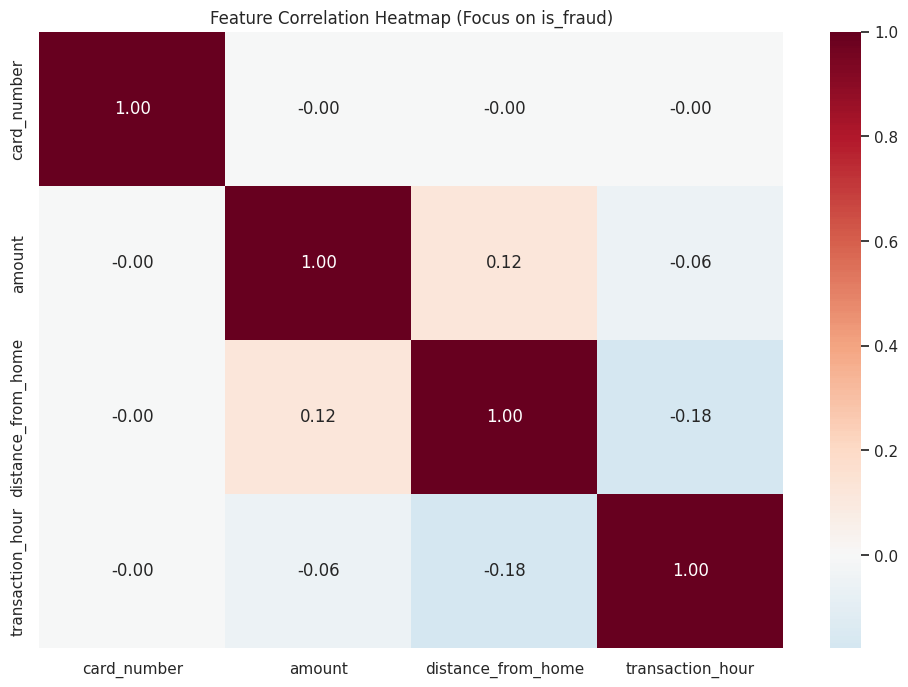

In [27]:
plt.figure(figsize=(12, 8))

# Select numeric columns and calculate correlation
# We include is_fraud to see what correlates most with the target
corr_matrix = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Feature Correlation Heatmap (Focus on is_fraud)')
plt.show()

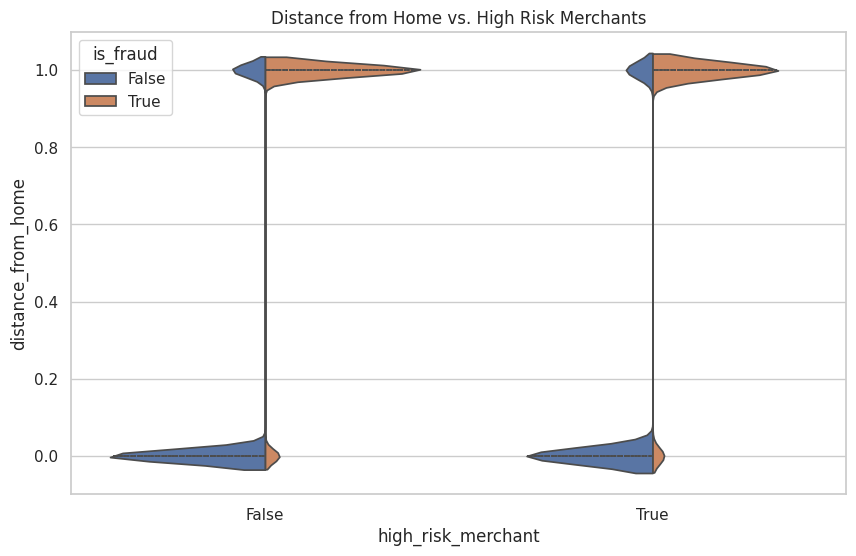

In [28]:
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='high_risk_merchant', y='distance_from_home', hue='is_fraud', split=True, inner="quart")
plt.title('Distance from Home vs. High Risk Merchants')
plt.show()

In [29]:
# Dataset Shape & Column Type Summary ──

print("=" * 60)
print("  DATASET OVERVIEW")
print("=" * 60)
print(f"  Rows:    {df.shape[0]:,}")
print(f"  Columns: {df.shape[1]}")
print(f"\n  Column Types:")
for dtype, count in df.dtypes.value_counts().items():
    print(f"    {dtype}: {count} columns")

print(f"\n  Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("    None found — dataset is clean")
else:
    for col in missing[missing > 0].index:
        print(f"    {col}: {missing[col]} ({missing[col]/len(df):.2%})")

print(f"\n  Memory Usage: {df.memory_usage(deep=True).sum() / (1024**2):.1f} MB")

print(f"\n  Unique Values Per Column:")
for col in df.columns:
    print(f"    {col}: {df[col].nunique():,} unique")



  DATASET OVERVIEW
  Rows:    7,483,766
  Columns: 22

  Column Types:
    object: 14 columns
    bool: 4 columns
    int64: 3 columns
    float64: 1 columns

  Missing Values:
    None found — dataset is clean

  Memory Usage: 7006.7 MB

  Unique Values Per Column:
    card_number: 5,000 unique
    date: 31 unique
    merchant_category: 8 unique
    merchant_type: 17 unique
    merchant: 105 unique
    amount: 2,831,167 unique
    currency: 11 unique
    country: 12 unique
    city: 11 unique
    city_size: 2 unique
    card_type: 5 unique
    card_present: 2 unique
    device: 9 unique
    channel: 3 unique
    device_fingerprint: 785,462 unique
    ip_address: 7,477,187 unique
    distance_from_home: 2 unique
    high_risk_merchant: 2 unique
    transaction_hour: 24 unique
    weekend_transaction: 2 unique
    velocity_last_hour: 7,483,740 unique
    is_fraud: 2 unique


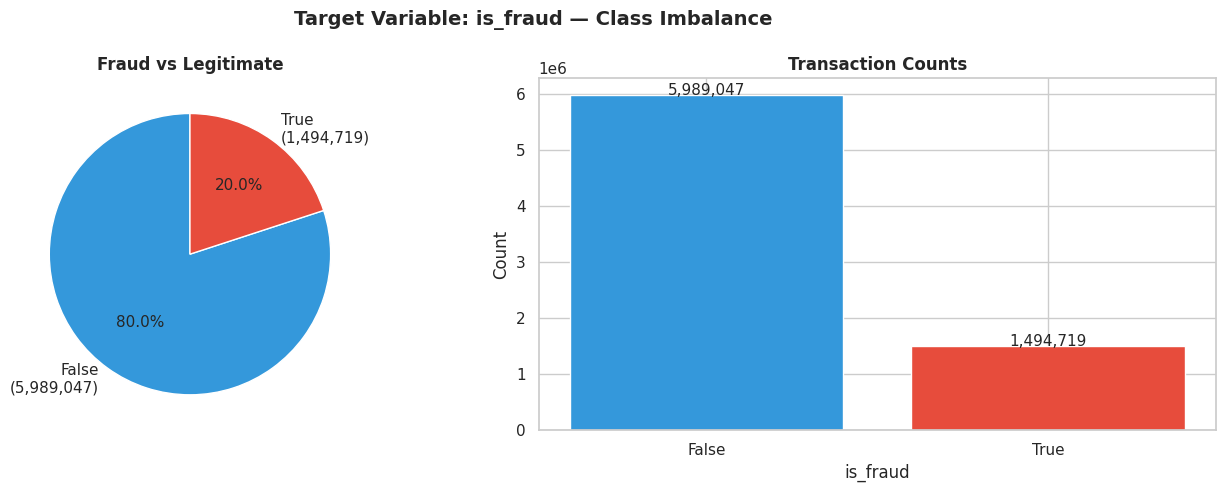


Fraud rate: 19.97%


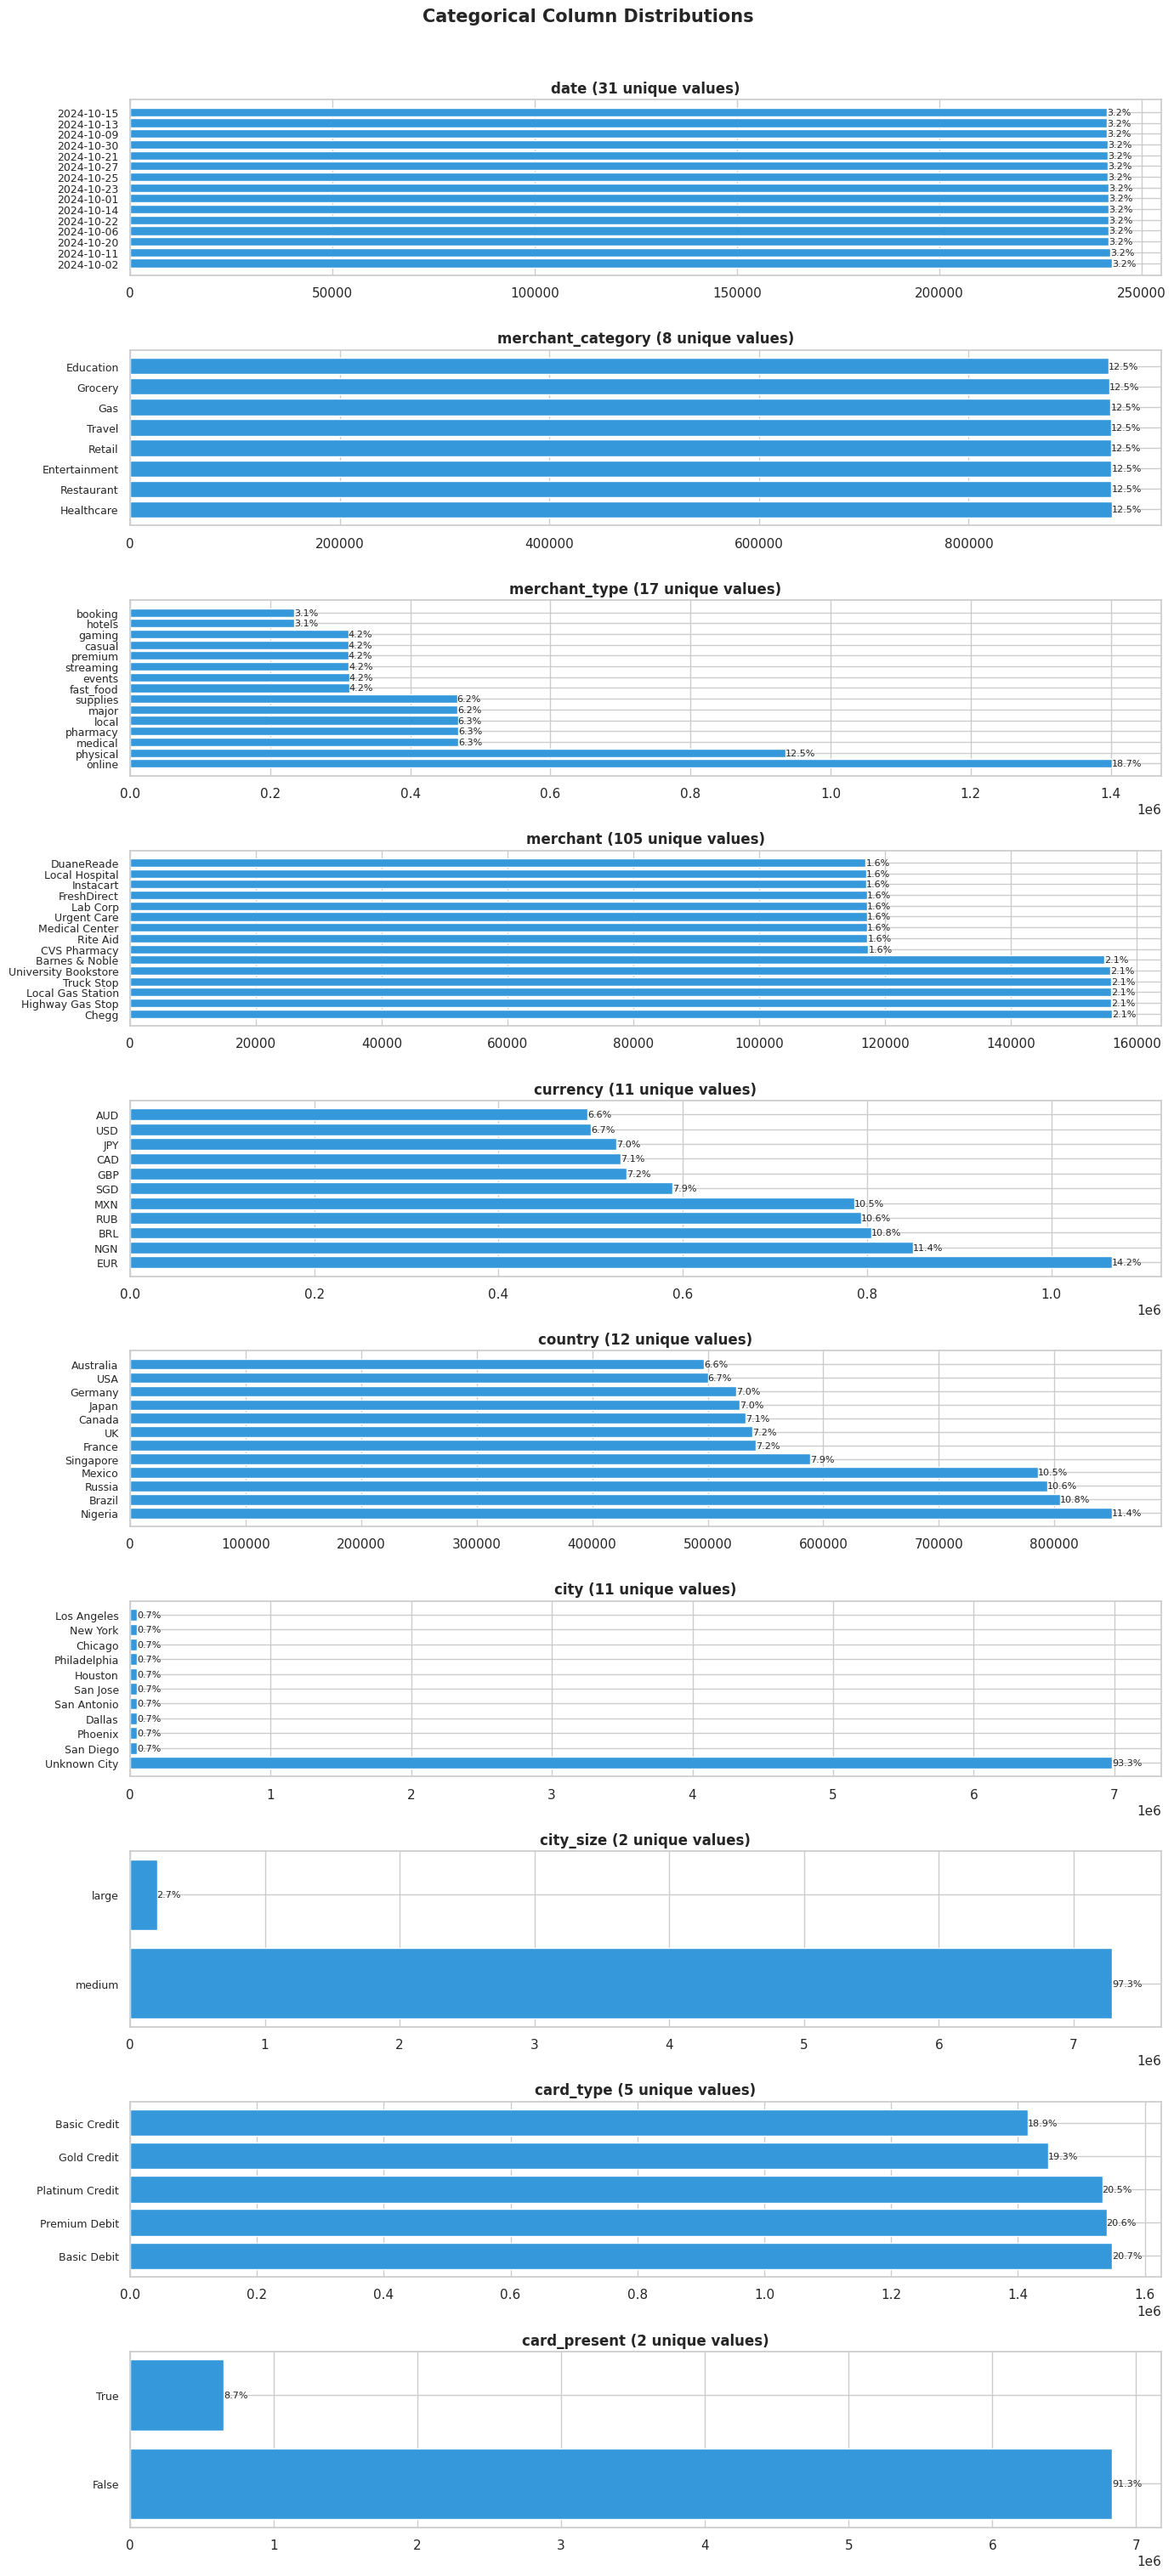

In [30]:

# ── NEW EDA 2: Class Imbalance — is_fraud (pie + bar) ──

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Target Variable: is_fraud — Class Imbalance", fontsize=14, fontweight="bold")

vc = df['is_fraud'].value_counts()
colors = ["#3498db", "#e74c3c"]
axes[0].pie(vc.values, labels=[f"{k}\n({v:,})" for k, v in vc.items()],
            autopct='%1.1f%%', colors=colors, startangle=90, textprops={'fontsize': 11})
axes[0].set_title("Fraud vs Legitimate", fontweight="bold")

bars = axes[1].bar(vc.index.astype(str), vc.values, color=colors, edgecolor="white")
for b, v in zip(bars, vc.values):
    axes[1].text(b.get_x() + b.get_width()/2, v + 500, f"{v:,}", ha="center", fontsize=11)
axes[1].set_title("Transaction Counts", fontweight="bold")
axes[1].set_ylabel("Count"); axes[1].set_xlabel("is_fraud")
plt.tight_layout(); plt.show()

fraud_rate = (df['is_fraud'] == True).mean() if df['is_fraud'].dtype == bool else (df['is_fraud'].astype(str) == 'True').mean()
print(f"\nFraud rate: {fraud_rate:.2%}")


# ── NEW EDA 3: All Categorical Distributions (horizontal bars) ──

cat_cols = df.select_dtypes(include=['object', 'bool', 'category']).columns.tolist()
# also check columns with few unique values
for col in df.columns:
    if df[col].nunique() < 20 and col not in cat_cols:
        cat_cols.append(col)

n = min(len(cat_cols), 10)  # max 10
fig, axes = plt.subplots(n, 1, figsize=(14, 3 * n))
if n == 1: axes = [axes]
fig.suptitle("Categorical Column Distributions", fontsize=15, fontweight="bold", y=1.01)

for ax, col in zip(axes, cat_cols[:n]):
    vc = df[col].astype(str).value_counts().head(15)  # top 15
    ax.barh(range(len(vc)), vc.values, color="#3498db", edgecolor="white")
    ax.set_yticks(range(len(vc)))
    ax.set_yticklabels(vc.index, fontsize=9)
    ax.set_title(f"{col} ({df[col].nunique()} unique values)", fontweight="bold")
    for i, v in enumerate(vc.values):
        ax.text(v + 50, i, f"{v/len(df):.1%}", va="center", fontsize=8)
plt.tight_layout(); plt.show()




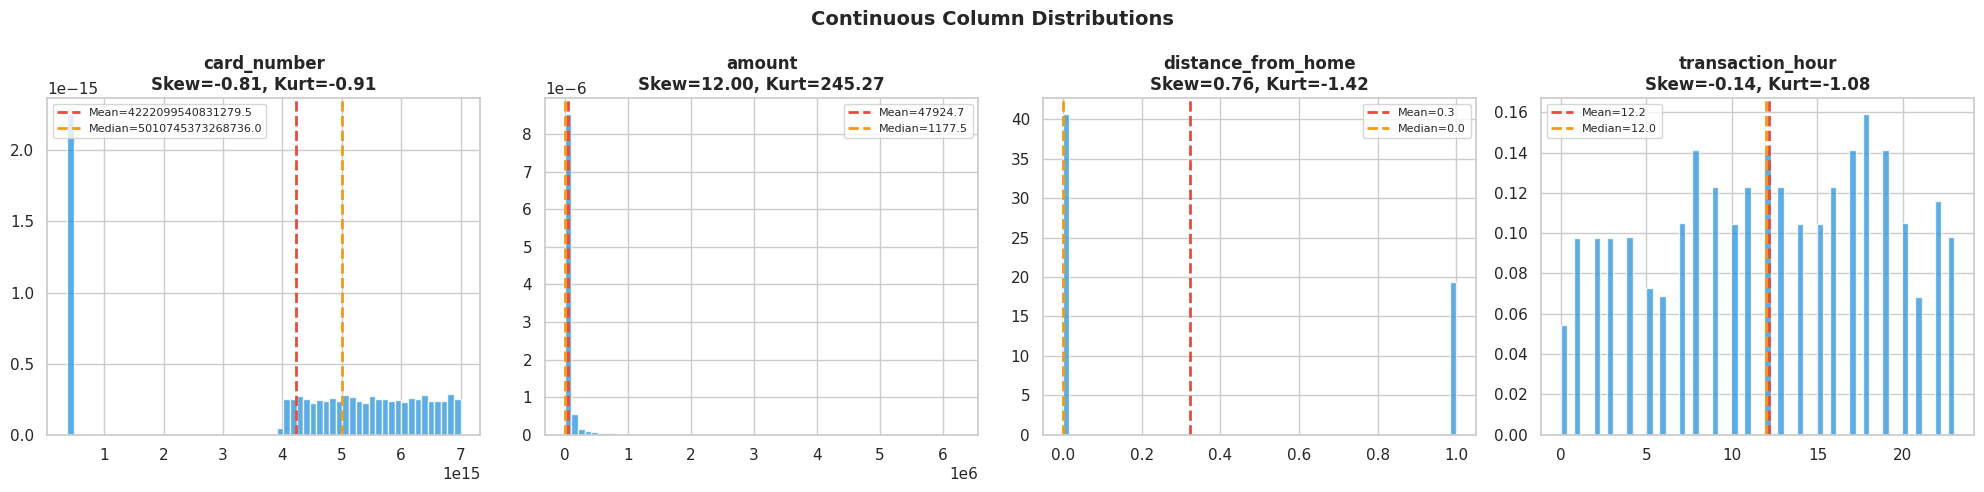


Continuous Column Statistics:
  card_number: mean=4222099540831279.50, median=5010745373268736.00, std=2341169514839418.00, skew=-0.81, kurtosis=-0.91
  amount: mean=47924.68, median=1177.45, std=177556.18, skew=12.00, kurtosis=245.27
  distance_from_home: mean=0.32, median=0.00, std=0.47, skew=0.76, kurtosis=-1.42
  transaction_hour: mean=12.15, median=12.00, std=6.54, skew=-0.14, kurtosis=-1.08


In [31]:
# ── NEW EDA 4: Continuous Distributions with Skewness & Kurtosis ──

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n = len(num_cols)

fig, axes = plt.subplots(1, min(n, 5), figsize=(5 * min(n, 5), 5))
if min(n, 5) == 1: axes = [axes]
fig.suptitle("Continuous Column Distributions", fontsize=14, fontweight="bold")

for ax, col in zip(axes, num_cols[:5]):
    vals = df[col].dropna()
    ax.hist(vals, bins=60, color="#3498db", edgecolor="white", alpha=0.8, density=True)
    ax.axvline(vals.mean(), color="#e74c3c", ls="--", lw=2, label=f"Mean={vals.mean():.1f}")
    ax.axvline(vals.median(), color="#f39c12", ls="--", lw=2, label=f"Median={vals.median():.1f}")
    ax.set_title(f"{col}\nSkew={vals.skew():.2f}, Kurt={vals.kurtosis():.2f}", fontweight="bold")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print("\nContinuous Column Statistics:")
for col in num_cols:
    v = df[col].dropna()
    print(f"  {col}: mean={v.mean():.2f}, median={v.median():.2f}, "
          f"std={v.std():.2f}, skew={v.skew():.2f}, kurtosis={v.kurtosis():.2f}")




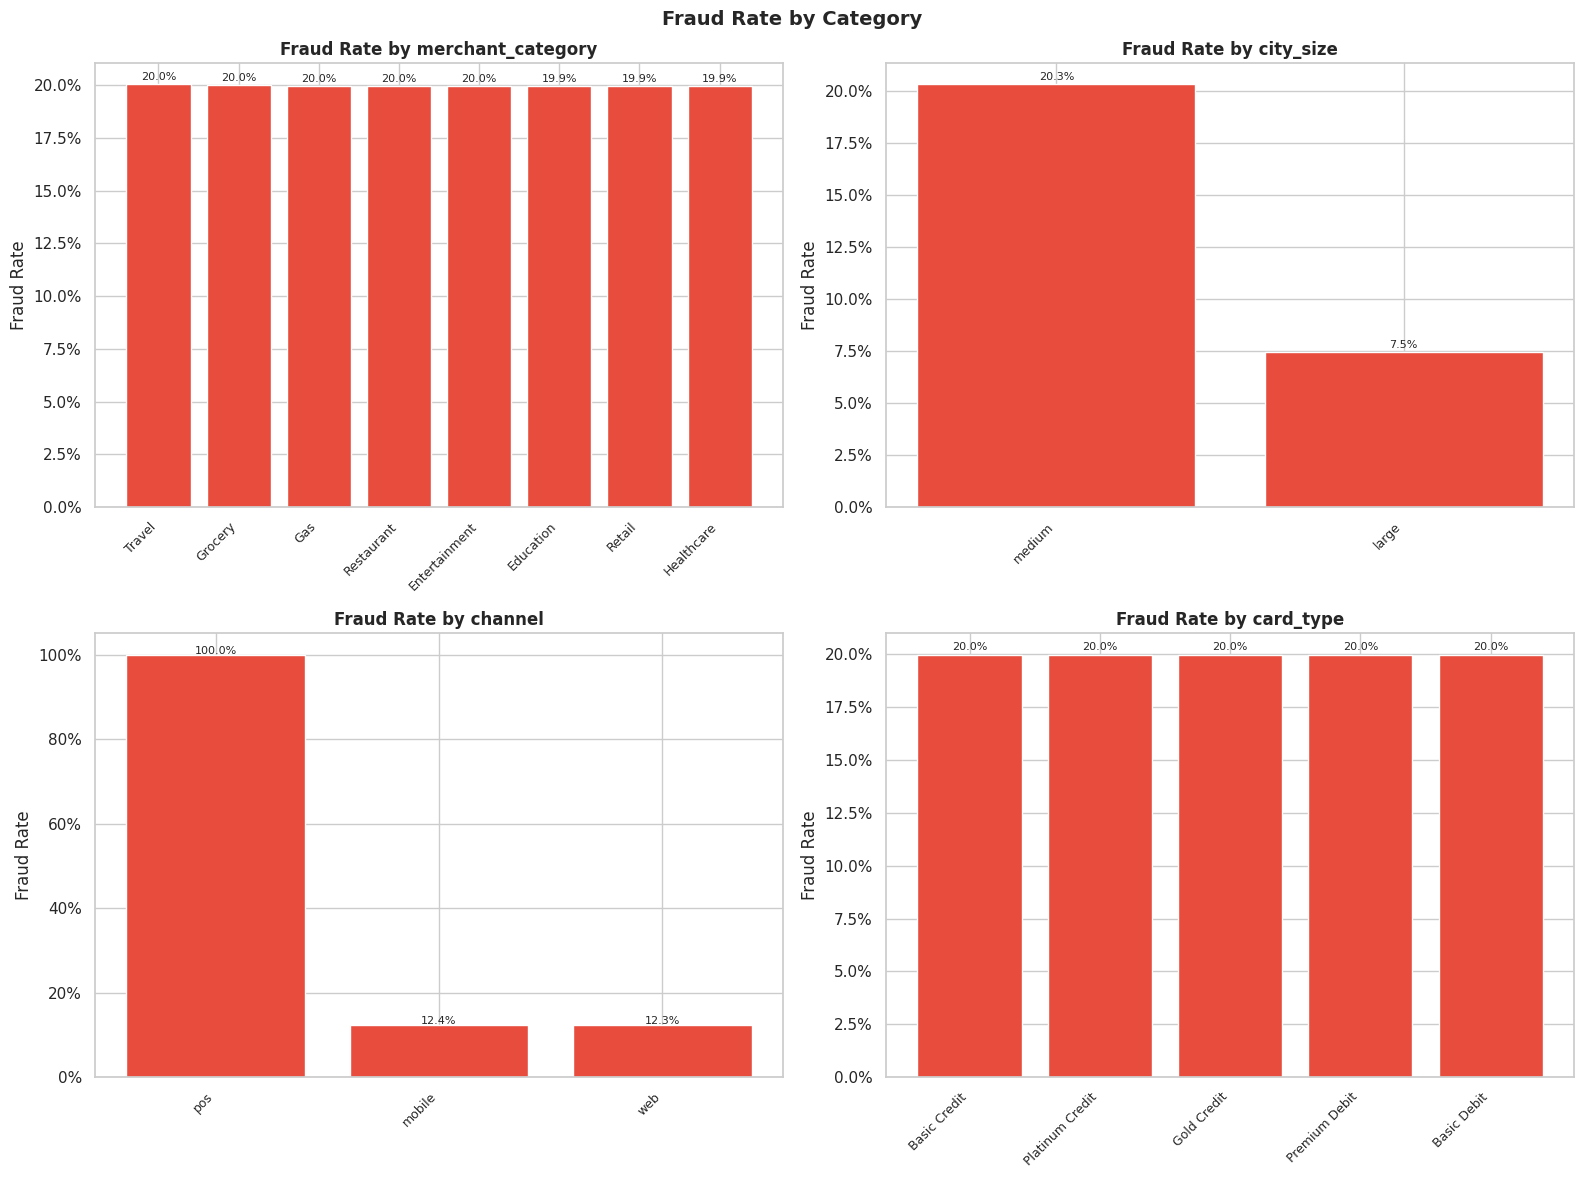

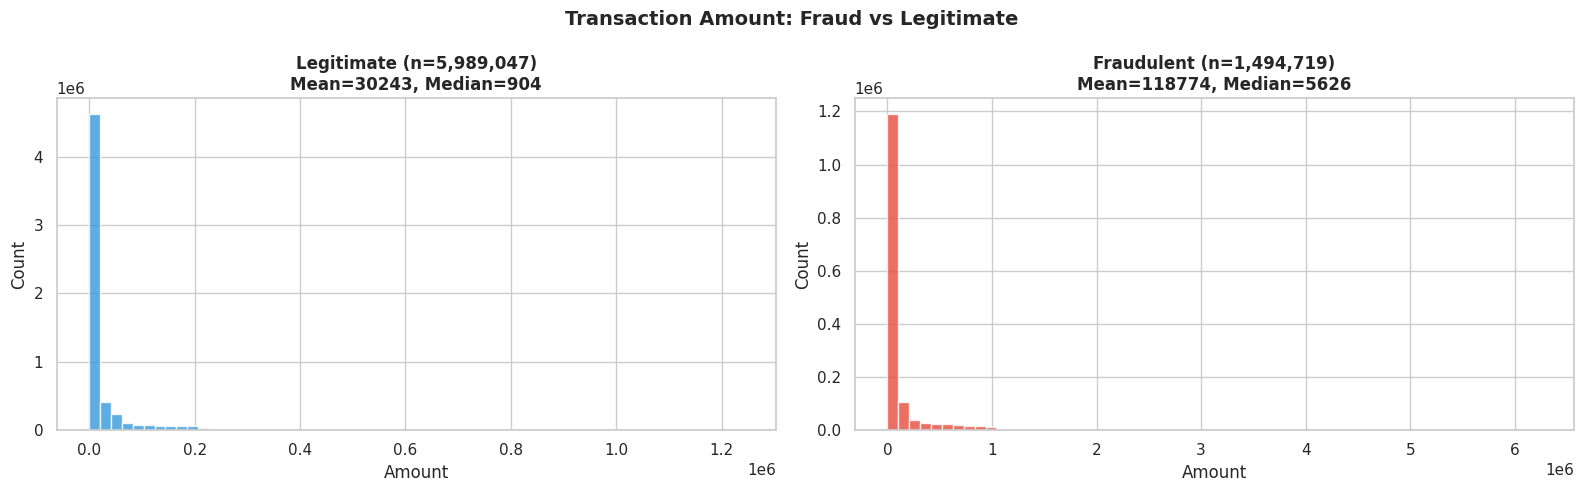

In [32]:
# ── NEW EDA 5: Fraud Rate by Key Categories ──

import matplotlib.ticker as mtick

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Fraud Rate by Category", fontsize=14, fontweight="bold")
axes = axes.flatten()

fraud_cols = ['merchant_category', 'city_size', 'channel', 'card_type']
fraud_cols = [c for c in fraud_cols if c in df.columns]

for ax, col in zip(axes, fraud_cols):
    if 'is_fraud' not in df.columns: continue
    fraud_rate_by = df.groupby(col)['is_fraud'].apply(
        lambda x: x.astype(str).isin(['True', '1', 'true']).mean()
    ).sort_values(ascending=False)
    bars = ax.bar(range(len(fraud_rate_by)), fraud_rate_by.values,
                  color="#e74c3c", edgecolor="white")
    ax.set_xticks(range(len(fraud_rate_by)))
    ax.set_xticklabels(fraud_rate_by.index, rotation=45, ha="right", fontsize=9)
    ax.set_title(f"Fraud Rate by {col}", fontweight="bold")
    ax.set_ylabel("Fraud Rate")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    for b, v in zip(bars, fraud_rate_by.values):
        ax.text(b.get_x() + b.get_width()/2, v + 0.002, f"{v:.1%}",
                ha="center", fontsize=8)
plt.tight_layout(); plt.show()


# ── NEW EDA 6: Amount — Fraud vs Legitimate Comparison ──

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Transaction Amount: Fraud vs Legitimate", fontsize=14, fontweight="bold")

fraud_mask = df['is_fraud'].astype(str).isin(['True', '1', 'true'])
for ax, (label, mask, clr) in zip(axes, [
    ("Legitimate", ~fraud_mask, "#3498db"),
    ("Fraudulent", fraud_mask, "#e74c3c"),
]):
    vals = pd.to_numeric(df.loc[mask, 'amount'], errors="coerce").dropna()
    ax.hist(vals, bins=60, color=clr, edgecolor="white", alpha=0.8)
    ax.set_title(f"{label} (n={len(vals):,})\nMean={vals.mean():.0f}, Median={vals.median():.0f}",
                 fontweight="bold")
    ax.set_xlabel("Amount"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()




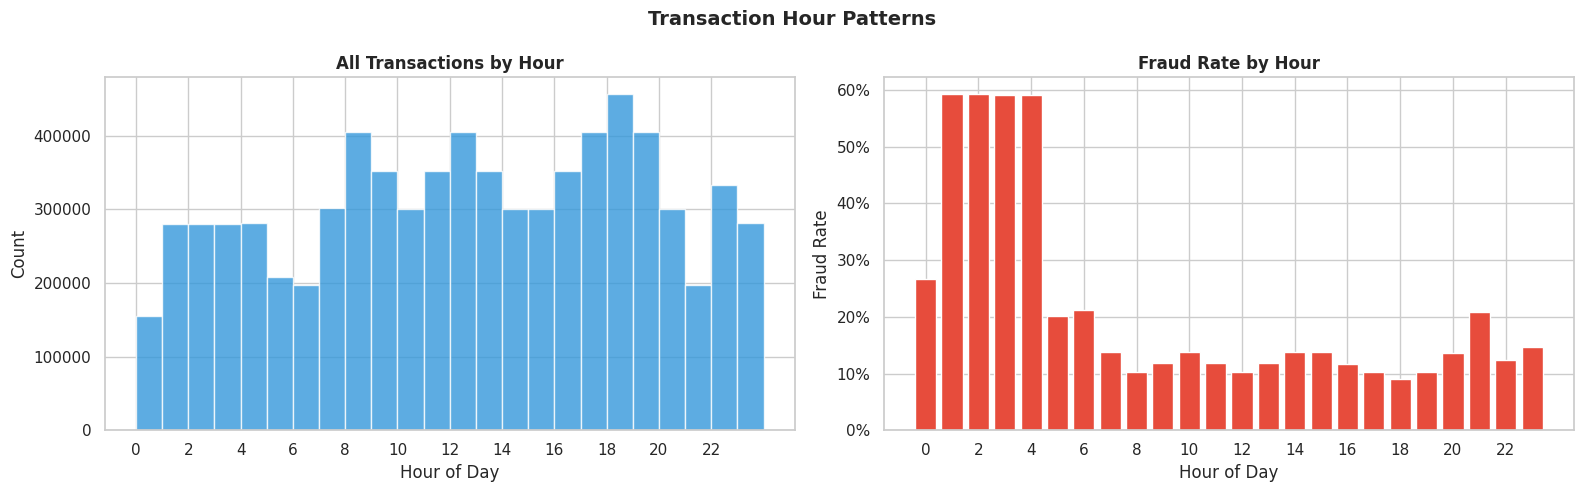

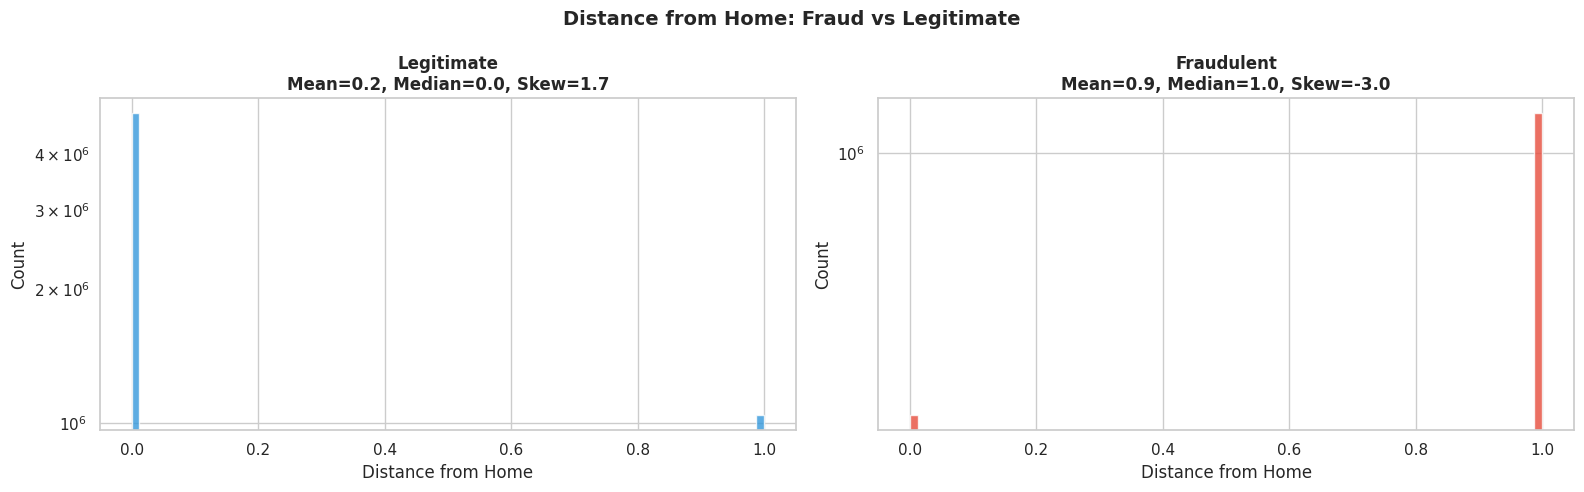


distance_from_home skewness: 0.76
This extreme skew explains why CTGAN struggles with this column (KS > 0.5)


In [33]:
# ── NEW EDA 7: Transaction Hour Pattern ──

if 'transaction_hour' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Transaction Hour Patterns", fontsize=14, fontweight="bold")

    # overall distribution
    axes[0].hist(df['transaction_hour'], bins=24, range=(0, 24),
                 color="#3498db", edgecolor="white", alpha=0.8)
    axes[0].set_title("All Transactions by Hour", fontweight="bold")
    axes[0].set_xlabel("Hour of Day"); axes[0].set_ylabel("Count")
    axes[0].set_xticks(range(0, 24, 2))

    # fraud vs legit by hour
    fraud_mask = df['is_fraud'].astype(str).isin(['True', '1', 'true'])
    hourly_fraud = df[fraud_mask]['transaction_hour'].value_counts().sort_index()
    hourly_legit = df[~fraud_mask]['transaction_hour'].value_counts().sort_index()
    hourly_rate = hourly_fraud / (hourly_fraud + hourly_legit)

    axes[1].bar(hourly_rate.index, hourly_rate.values, color="#e74c3c", edgecolor="white")
    axes[1].set_title("Fraud Rate by Hour", fontweight="bold")
    axes[1].set_xlabel("Hour of Day"); axes[1].set_ylabel("Fraud Rate")
    axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    axes[1].set_xticks(range(0, 24, 2))

    plt.tight_layout(); plt.show()


# ── NEW EDA 8: Distance from Home — Fraud vs Legit (with log scale) ──

if 'distance_from_home' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle("Distance from Home: Fraud vs Legitimate", fontsize=14, fontweight="bold")

    fraud_mask = df['is_fraud'].astype(str).isin(['True', '1', 'true'])

    for ax, (label, mask, clr) in zip(axes, [
        ("Legitimate", ~fraud_mask, "#3498db"),
        ("Fraudulent", fraud_mask, "#e74c3c"),
    ]):
        vals = pd.to_numeric(df.loc[mask, 'distance_from_home'], errors="coerce").dropna()
        ax.hist(vals, bins=80, color=clr, edgecolor="white", alpha=0.8)
        ax.set_title(f"{label}\nMean={vals.mean():.1f}, Median={vals.median():.1f}, Skew={vals.skew():.1f}",
                     fontweight="bold")
        ax.set_xlabel("Distance from Home"); ax.set_ylabel("Count")
        ax.set_yscale("log")  # log scale because of extreme skew

    plt.tight_layout(); plt.show()

    print(f"\ndistance_from_home skewness: {df['distance_from_home'].skew():.2f}")
    print(f"This extreme skew explains why CTGAN struggles with this column (KS > 0.5)")




In [ ]:
  # Columns Dropped vs Kept — Justification Table ──

all_original_cols = df.columns.tolist()
keep_cols = ['merchant_category', 'merchant_type', 'amount', 'city', 'city_size',
             'card_type', 'channel', 'distance_from_home', 'high_risk_merchant',
             'transaction_hour', 'is_fraud']

print("\n" + "=" * 70)
print("  COLUMN SELECTION SUMMARY")
print("=" * 70)
print(f"\n  Original columns: {len(all_original_cols)}")
print(f"  Kept for CTGAN:   {len(keep_cols)}")
print(f"  Dropped:          {len(all_original_cols) - len(keep_cols)}")

print(f"\n  KEPT COLUMNS:")
for col in keep_cols:
    if col in df.columns:
        dtype = "Categorical" if df[col].nunique() < 30 else "Continuous"
        print(f"    ✓ {col:<25s} {dtype:<15s} {df[col].nunique():>6} unique")

print(f"\n  DROPPED COLUMNS (with reason):")
drop_reasons = {
    'transaction_id': 'Unique identifier — no distributional info',
    'customer_id': 'Unique identifier — no distributional info',
    'card_number': 'Near-unique identifier — no distributional info',
    'date': 'Temporal — outside project scope',
    'timestamp': 'Temporal — outside project scope',
    'merchant': 'High cardinality (thousands of unique values)',
    'device': 'High cardinality device identifiers',
    'ip_address': 'Unique network identifier',
    'device_fingerprint': 'Unique nested JSON field',
    'velocity_last_hour': 'Derived feature — redundant',
    'country': 'Low variance (mostly single country)',
    'currency': 'Low variance (mostly single currency)',
    'weekend_transaction': 'Derived from date — redundant',
    'card_present': 'Binary — low information content',
}
for col in all_original_cols:
    if col not in keep_cols:
        reason = drop_reasons.get(col, 'Not needed for CTGAN training')
        print(f"    ✗ {col:<25s} {reason}")


# **Preprocessing**

In [ ]:
import pandas as pd
import numpy as np

# 1. Define a list of common "unknown" placeholders found in your EDA
unknown_placeholders = ['Unknown City', 'Unknown', 'unknown', '?', 'N/A', 'None']

# 2. Replace these string placeholders with actual NumPy NaNs
df.replace(unknown_placeholders, np.nan, inplace=True)

print(f"Dataset shape after marking unknowns: {df.shape}")

Dataset shape after marking unknowns: (7483766, 22)


In [ ]:
# 1. Check how many nulls we have per column
print("Null values per column:")
print(df.isnull().sum())

# 2. Remove rows with any null values
# This ensures every row used for training has a full 'story' for the GAN to learn
df_clean = df.dropna().reset_index(drop=True)

print(f"Final dataset shape after removing nulls: {df_clean.shape}")

Null values per column:
card_number                  0
date                         0
merchant_category            0
merchant_type                0
merchant                     0
amount                       0
currency                     0
country                      0
city                   6983706
city_size                    0
card_type                    0
card_present                 0
device                       0
channel                      0
device_fingerprint           0
ip_address                   0
distance_from_home           0
high_risk_merchant           0
transaction_hour             0
weekend_transaction          0
velocity_last_hour           0
is_fraud                     0
dtype: int64
Final dataset shape after removing nulls: (500060, 22)


In [ ]:
def finalize_for_ctgan(df):
    # A. Feature Selection: Remove columns with zero variance
    # (e.g., if you only have one date, it won't help the model learn)
    for col in df.columns:
        if df[col].nunique() <= 1:
            print(f"Dropping constant column: {col}")
            df = df.drop(columns=[col])

    # B. Consistency: Strip leading/trailing whitespaces from categories
    object_cols = df.select_dtypes(include=['object']).columns
    for col in object_cols:
        df[col] = df[col].astype(str).str.strip()

    # C. Data Type Enforcement
    # CTGAN needs a clear distinction between 'Discrete' and 'Continuous'
    # Cast potential categorical columns to 'category'
    categorical_candidates = [
        'merchant_category', 'merchant_type', 'merchant', 'currency',
        'country', 'city', 'city_size', 'card_type', 'device', 'channel',
        'high_risk_merchant', 'weekend_transaction', 'is_fraud'
    ]

    # Only cast if the column still exists in the dataframe
    existing_cats = [c for c in categorical_candidates if c in df.columns]
    for col in existing_cats:
        df[col] = df[col].astype('category')

    return df, existing_cats

# Execute
df_final, discrete_columns = finalize_for_ctgan(df_clean)

print("\n--- Preprocessing Complete ---")
print(f"Ready for HITL-CTGAN training with {len(discrete_columns)} discrete columns.")
display(df_final.head())

Dropping constant column: currency
Dropping constant column: country

--- Preprocessing Complete ---
Ready for HITL-CTGAN training with 11 discrete columns.


,card_number,date,merchant_category,merchant_type,merchant,amount,city,city_size,card_type,card_present,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
0,4068844001919119,2024-09-30,Restaurant,premium,Capital Grille,360.46,San Antonio,medium,Premium Debit,False,iOS App,mobile,fb6efe6bfd9c30af9eb595895498957a,12.227.123.93,0,False,0,False,"{'num_transactions': 311, 'total_amount': 7829...",False
1,5753612665208104,2024-09-30,Grocery,physical,Trader Joe's,353.16,Philadelphia,medium,Premium Debit,False,Chrome,web,7a2df8666781b3a76734c2ceec78b23f,213.136.170.156,0,False,0,False,"{'num_transactions': 754, 'total_amount': 1869...",False
2,6799096125677377,2024-09-30,Restaurant,premium,Capital Grille,463.49,San Antonio,medium,Premium Debit,False,Android App,mobile,8ed7da0bb597d747048f0bcab829e3c8,89.11.200.232,1,False,0,False,"{'num_transactions': 1488, 'total_amount': 464...",False
3,6115864323767762,2024-09-30,Retail,physical,Nike Store,429.89,Phoenix,medium,Basic Debit,False,Edge,web,e737e43bf25016900dce268b42dfd3d3,36.247.15.242,0,False,0,False,"{'num_transactions': 1656, 'total_amount': 382...",False
4,377986383426959,2024-09-30,Education,online,MasterClass,868.44,San Diego,medium,Platinum Credit,False,iOS App,mobile,0669f577145a7d1cfa6b8c61834043e5,199.194.203.35,1,False,0,False,"{'num_transactions': 317, 'total_amount': 9255...",False


In [ ]:
df

,card_number,date,merchant_category,merchant_type,merchant,amount,currency,country,city,city_size,...,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
0,6646734767813109,2024-09-30,Restaurant,fast_food,Taco Bell,294.87,GBP,UK,NaN,medium,...,iOS App,mobile,e8e6160445c935fd0001501e4cbac8bc,197.153.60.199,0,False,0,False,"{'num_transactions': 1197, 'total_amount': 334...",False
1,376800864692727,2024-09-30,Entertainment,gaming,Steam,3368.97,BRL,Brazil,NaN,medium,...,Edge,web,a73043a57091e775af37f252b3a32af9,208.123.221.203,1,True,0,False,"{'num_transactions': 509, 'total_amount': 2011...",True
2,5251909460951913,2024-09-30,Grocery,physical,Whole Foods,102582.38,JPY,Japan,NaN,medium,...,Firefox,web,218864e94ceaa41577d216b149722261,10.194.159.204,0,False,0,False,"{'num_transactions': 332, 'total_amount': 3916...",False
3,376079286931183,2024-09-30,Gas,major,Exxon,630.60,AUD,Australia,NaN,medium,...,iOS App,mobile,70423fa3a1e74d01203cf93b51b9631d,17.230.177.225,0,False,0,False,"{'num_transactions': 764, 'total_amount': 2201...",False
4,6172948052178810,2024-09-30,Healthcare,medical,Medical Center,724949.27,NGN,Nigeria,NaN,medium,...,Chrome,web,9880776c7b6038f2af86bd4e18a1b1a4,136.241.219.151,1,False,0,False,"{'num_transactions': 218, 'total_amount': 4827...",True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7483761,377055034743699,2024-10-30,Retail,online,AliExpress,887.32,SGD,Singapore,NaN,medium,...,Safari,web,2e37bb086e754bfaf2ec3806dcac8d98,248.8.111.152,0,False,23,False,"{'num_transactions': 1, 'total_amount': 1521.7...",False
7483762,373625915641065,2024-10-30,Grocery,physical,Kroger,356.06,EUR,France,NaN,medium,...,Chrome,web,459c67dbfbb15019df8088fc0f2ffe1d,224.123.137.90,0,False,23,False,"{'num_transactions': 0, 'total_amount': 356.06...",False
7483763,6702342842796660,2024-10-30,Grocery,physical,Kroger,391.96,SGD,Singapore,NaN,medium,...,Safari,web,337d36a8f5e811564a1dd3c255db01dd,31.196.9.234,0,False,23,False,"{'num_transactions': 0, 'total_amount': 391.96...",False
7483764,374615717295581,2024-10-30,Retail,online,eBay,601.71,USD,USA,Chicago,large,...,Firefox,web,52874c17f4ab0846fac1aed0c66e8551,188.74.107.8,0,False,23,False,"{'num_transactions': 2, 'total_amount': 1474.5...",False


In [ ]:
df.to_csv('final_data.csv', index=False)

In [ ]:
print(df.isnull().sum())

card_number                  0
date                         0
merchant_category            0
merchant_type                0
merchant                     0
amount                       0
currency                     0
country                      0
city                   6983706
city_size                    0
card_type                    0
card_present                 0
device                       0
channel                      0
device_fingerprint           0
ip_address                   0
distance_from_home           0
high_risk_merchant           0
transaction_hour             0
weekend_transaction          0
velocity_last_hour           0
is_fraud                     0
dtype: int64


In [ ]:
import pandas as pd
import numpy as np

# 1. Define columns to KEEP (Inverse of dropping IDs)
# This prevents loading transaction_id, customer_id, ip_address, etc.
all_cols = df.columns.tolist()
cols_to_exclude = ['transaction_id', 'customer_id', 'velocity_last_hour', 'ip_address', 'device_fingerprint', 'card_number']
keep_cols = [c for c in all_cols if c not in cols_to_exclude]

# 2. Load the dataset with only necessary columns
# This significantly reduces the memory footprint immediately
#df = pd.read_csv(full_path, usecols=keep_cols)

# 3. Handle 'Unknown' Cities and Nulls immediately
# Filtering 'Unknown City' early frees up space
df = df[df['city'] != 'Unknown City']
df = df.dropna()

print(f"Size after initial cleaning: {df.shape}")

Size after initial cleaning: (500060, 22)


In [ ]:
df

,card_number,date,merchant_category,merchant_type,merchant,amount,currency,country,city,city_size,...,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
35,4068844001919119,2024-09-30,Restaurant,premium,Capital Grille,360.46,USD,USA,San Antonio,medium,...,iOS App,mobile,fb6efe6bfd9c30af9eb595895498957a,12.227.123.93,0,False,0,False,"{'num_transactions': 311, 'total_amount': 7829...",False
36,5753612665208104,2024-09-30,Grocery,physical,Trader Joe's,353.16,USD,USA,Philadelphia,medium,...,Chrome,web,7a2df8666781b3a76734c2ceec78b23f,213.136.170.156,0,False,0,False,"{'num_transactions': 754, 'total_amount': 1869...",False
39,6799096125677377,2024-09-30,Restaurant,premium,Capital Grille,463.49,USD,USA,San Antonio,medium,...,Android App,mobile,8ed7da0bb597d747048f0bcab829e3c8,89.11.200.232,1,False,0,False,"{'num_transactions': 1488, 'total_amount': 464...",False
58,6115864323767762,2024-09-30,Retail,physical,Nike Store,429.89,USD,USA,Phoenix,medium,...,Edge,web,e737e43bf25016900dce268b42dfd3d3,36.247.15.242,0,False,0,False,"{'num_transactions': 1656, 'total_amount': 382...",False
63,377986383426959,2024-09-30,Education,online,MasterClass,868.44,USD,USA,San Diego,medium,...,iOS App,mobile,0669f577145a7d1cfa6b8c61834043e5,199.194.203.35,1,False,0,False,"{'num_transactions': 317, 'total_amount': 9255...",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7483727,6192184248118504,2024-10-30,Entertainment,streaming,Apple Music,349.52,USD,USA,San Jose,medium,...,Edge,web,dffaf60ba9ec8029c7a06060b5a616e6,70.99.231.176,0,True,23,False,"{'num_transactions': 0, 'total_amount': 349.52...",False
7483754,6298127984776079,2024-10-30,Gas,major,Shell,3.57,USD,USA,Houston,large,...,Magnetic Stripe,pos,adecdd7334d256a433ddd245b24580a7,25.195.70.176,1,False,23,False,"{'num_transactions': 0, 'total_amount': 3.57, ...",True
7483756,5197019555027681,2024-10-30,Healthcare,pharmacy,Walgreens,2048.38,USD,USA,Phoenix,medium,...,Android App,mobile,67bc3dd9280aed45360d3f39596d2dee,125.96.245.26,0,False,23,False,"{'num_transactions': 0, 'total_amount': 2048.3...",False
7483759,6124386606160894,2024-10-30,Restaurant,fast_food,McDonald's,160.18,USD,USA,Los Angeles,large,...,Chrome,web,05c12b3f80b388679de5491805c2bfd1,152.62.36.252,0,False,23,False,"{'num_transactions': 2, 'total_amount': 130293...",False


In [ ]:
from sklearn.model_selection import train_test_split

# Aim for 200,000 to 500,000 rows - plenty for CTGAN to learn distributions
target_size = 300000
current_size = len(df)

if current_size > target_size:
    # Stratify by 'is_fraud' to keep the fraud/legit ratio identical to the original
    df, _ = train_test_split(
        df,
        train_size=target_size,
        stratify=df['is_fraud'],
        random_state=42
    )

print(f"Reduced dataset size to: {df.shape}")

Reduced dataset size to: (300000, 22)


In [ ]:
df

,card_number,date,merchant_category,merchant_type,merchant,amount,currency,country,city,city_size,...,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
454751,6255377551861223,2024-10-01,Entertainment,gaming,Steam,945.26,USD,USA,San Jose,medium,...,Firefox,web,6392db40099816f5b60fe989ddc3e34e,187.14.219.96,1,True,20,False,"{'num_transactions': 841, 'total_amount': 2411...",True
6451005,5517591606898669,2024-10-26,Grocery,online,Amazon Fresh,612.92,USD,USA,Dallas,medium,...,Android App,mobile,6c50647fae3b6e7fae715ca52d9a15a2,139.78.0.107,0,False,17,True,"{'num_transactions': 194, 'total_amount': 5688...",False
6777277,4452967213903508,2024-10-28,Restaurant,casual,Red Lobster,1038.68,USD,USA,Houston,large,...,Edge,web,1d43a46065da2be6c9fa603111961bd4,47.148.67.149,0,False,2,False,"{'num_transactions': 45, 'total_amount': 50109...",False
355283,4895095550931638,2024-10-01,Travel,booking,Kayak,318.94,USD,USA,Phoenix,medium,...,Chrome,web,5b53bcdaf82a60a63e6f1f8355291671,19.192.28.218,0,True,12,False,"{'num_transactions': 261, 'total_amount': 2153...",False
4002738,5789322251574954,2024-10-16,Grocery,physical,Kroger,309.92,USD,USA,Houston,large,...,Safari,web,fbaf40b53ba8d65e9361b03202877cf2,45.232.19.164,0,False,14,False,"{'num_transactions': 303, 'total_amount': 8515...",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5205967,6952964019036252,2024-10-21,Restaurant,casual,Chili's,129.96,USD,USA,Chicago,large,...,Safari,web,19e23bfac0c4e23df49f7f7a5776b6d9,123.60.59.197,0,False,14,False,"{'num_transactions': 141, 'total_amount': 1957...",False
4684086,370550411142421,2024-10-19,Healthcare,medical,Urgent Care,636.77,USD,USA,Chicago,large,...,iOS App,mobile,083aa9ae08756d5d62bb15332691aa45,181.192.126.4,0,False,10,True,"{'num_transactions': 364, 'total_amount': 1059...",False
3698104,372516849574269,2024-10-15,Entertainment,events,StubHub,1338.03,USD,USA,Philadelphia,medium,...,Android App,mobile,f6bf4dc55b74ffdb9e02129201d38b57,16.59.22.209,0,True,8,False,"{'num_transactions': 196, 'total_amount': 8082...",False
4398241,5348150591223832,2024-10-18,Entertainment,events,Regal Cinemas,125.21,USD,USA,Houston,large,...,Firefox,web,3788e528f05ebf78e858d42efad1e1c7,118.177.138.51,0,True,6,False,"{'num_transactions': 285, 'total_amount': 9106...",False


In [ ]:
df.columns

Index(['card_number', 'date', 'merchant_category', 'merchant_type', 'merchant',
       'amount', 'currency', 'country', 'city', 'city_size', 'card_type',
       'card_present', 'device', 'channel', 'device_fingerprint', 'ip_address',
       'distance_from_home', 'high_risk_merchant', 'transaction_hour',
       'weekend_transaction', 'velocity_last_hour', 'is_fraud'],
      dtype='object')

In [ ]:
def optimize_and_clean(df):
    # 1. Simplify Date (as requested: date only)
    df['date'] = pd.to_datetime(df['date']).dt.date

    # 2. Downcast Numerical Columns (float64 -> float32)
    # This cuts memory usage of numeric columns in half
    fcols = df.select_dtypes('float').columns
    df[fcols] = df[fcols].apply(pd.to_numeric, downcast='float')

    icols = df.select_dtypes('integer').columns
    df[icols] = df[icols].apply(pd.to_numeric, downcast='integer')

    # 3. Convert Strings to Categories
    # Essential for CTGAN and memory efficiency
    cat_cols = df.select_dtypes('object').columns
    for col in cat_cols:
        df[col] = df[col].astype('category')

    return df

df_final = optimize_and_clean(df)
print(f"Final Memory Usage: {df_final.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Final Memory Usage: 107.36 MB


In [ ]:
df

,card_number,date,merchant_category,merchant_type,merchant,amount,currency,country,city,city_size,...,device,channel,device_fingerprint,ip_address,distance_from_home,high_risk_merchant,transaction_hour,weekend_transaction,velocity_last_hour,is_fraud
454751,6255377551861223,2024-10-01,Entertainment,gaming,Steam,945.260010,USD,USA,San Jose,medium,...,Firefox,web,6392db40099816f5b60fe989ddc3e34e,187.14.219.96,1,True,20,False,"{'num_transactions': 841, 'total_amount': 2411...",True
6451005,5517591606898669,2024-10-26,Grocery,online,Amazon Fresh,612.919983,USD,USA,Dallas,medium,...,Android App,mobile,6c50647fae3b6e7fae715ca52d9a15a2,139.78.0.107,0,False,17,True,"{'num_transactions': 194, 'total_amount': 5688...",False
6777277,4452967213903508,2024-10-28,Restaurant,casual,Red Lobster,1038.680054,USD,USA,Houston,large,...,Edge,web,1d43a46065da2be6c9fa603111961bd4,47.148.67.149,0,False,2,False,"{'num_transactions': 45, 'total_amount': 50109...",False
355283,4895095550931638,2024-10-01,Travel,booking,Kayak,318.940002,USD,USA,Phoenix,medium,...,Chrome,web,5b53bcdaf82a60a63e6f1f8355291671,19.192.28.218,0,True,12,False,"{'num_transactions': 261, 'total_amount': 2153...",False
4002738,5789322251574954,2024-10-16,Grocery,physical,Kroger,309.920013,USD,USA,Houston,large,...,Safari,web,fbaf40b53ba8d65e9361b03202877cf2,45.232.19.164,0,False,14,False,"{'num_transactions': 303, 'total_amount': 8515...",False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5205967,6952964019036252,2024-10-21,Restaurant,casual,Chili's,129.960007,USD,USA,Chicago,large,...,Safari,web,19e23bfac0c4e23df49f7f7a5776b6d9,123.60.59.197,0,False,14,False,"{'num_transactions': 141, 'total_amount': 1957...",False
4684086,370550411142421,2024-10-19,Healthcare,medical,Urgent Care,636.770020,USD,USA,Chicago,large,...,iOS App,mobile,083aa9ae08756d5d62bb15332691aa45,181.192.126.4,0,False,10,True,"{'num_transactions': 364, 'total_amount': 1059...",False
3698104,372516849574269,2024-10-15,Entertainment,events,StubHub,1338.030029,USD,USA,Philadelphia,medium,...,Android App,mobile,f6bf4dc55b74ffdb9e02129201d38b57,16.59.22.209,0,True,8,False,"{'num_transactions': 196, 'total_amount': 8082...",False
4398241,5348150591223832,2024-10-18,Entertainment,events,Regal Cinemas,125.209999,USD,USA,Houston,large,...,Firefox,web,3788e528f05ebf78e858d42efad1e1c7,118.177.138.51,0,True,6,False,"{'num_transactions': 285, 'total_amount': 9106...",False


In [ ]:
df.to_csv('final_data.csv', index=False)

#End